In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
df_tsv = pd.read_csv(
    "/workspaces/Effector-Structure-Prediction/04_results_tsv/pdb_metadata_af3.tsv",
    sep="\t"
)

df_tsv.columns = df_tsv.columns.str.strip()

df_excel = pd.read_excel(
    "/workspaces/Effector-Structure-Prediction/80_fungal_effector_structures_V9.xlsx", sheet_name="Structures", skiprows=5
)

df_excel.columns = df_excel.columns.str.strip()

df_excel_subset = df_excel[
    [
        "PDB_ID",
        "Structural family (inferred from La Naour Vernet et al. (2025))",
        "How many protein identities in crystal structure",
        "Method",
        "Resolution",
    ]
]

# Merge into the TSV dataframe
df_merged = df_tsv.merge(
    df_excel_subset,
    on="PDB_ID",
    how="left"
)

df=df_merged

df = df[df["Effector"] == 1]

print(df_merged.columns.tolist())


['PDB_ID', 'Chain', 'Annotation', 'Organism', 'Effector', 'Deposition_date', 'TM_score_crystal_esm', 'TM_score_pred_esm', 'RMSD_esm', 'Aligned_length_esm', 'Seq_ID_esm', 'Pred_length_esm', 'Experimental_length_esm', 'Coverage_esm', 'runtime_seconds_esm', 'TM_score_crystal_af2', 'TM_score_pred_af2', 'RMSD_af2', 'Aligned_length_af2', 'Seq_ID_af2', 'Pred_length_af2', 'Experimental_length_af2', 'Coverage_af2', 'TM_score_crystal_af3', 'TM_score_pred_af3', 'RMSD_af3', 'Aligned_length_af3', 'Seq_ID_af3', 'Pred_length_af3', 'Experimental_length_af3', 'Coverage_af3', 'runtime_seconds_af3', 'Structural family (inferred from La Naour Vernet et al. (2025))', 'How many protein identities in crystal structure', 'Method', 'Resolution']


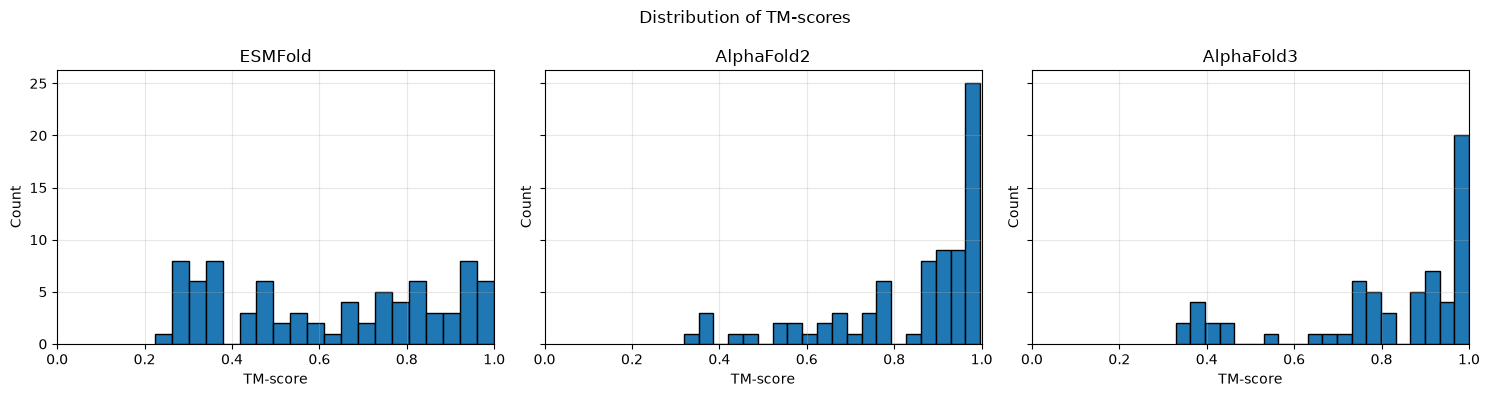

In [ ]:
tm_columns = [
    "TM_score_crystal_esm",
    "TM_score_crystal_af2",
    "TM_score_crystal_af3",
]

titles = [
    "ESMFold",
    "AlphaFold2",
    "AlphaFold3",
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for ax, col, title in zip(axes, tm_columns, titles):

    ax.hist(
        df[col].dropna(),
        bins=20,
        edgecolor="black"
    )

    ax.set_title(title)
    ax.set_xlabel("TM-score")
    ax.set_ylabel("Count")
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.3)

fig.suptitle("Distribution of TM-scores")
plt.tight_layout()
plt.show()

/tmp/ipykernel_31172/3168087499.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
/tmp/ipykernel_31172/3168087499.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
/tmp/ipykernel_31172/3168087499.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


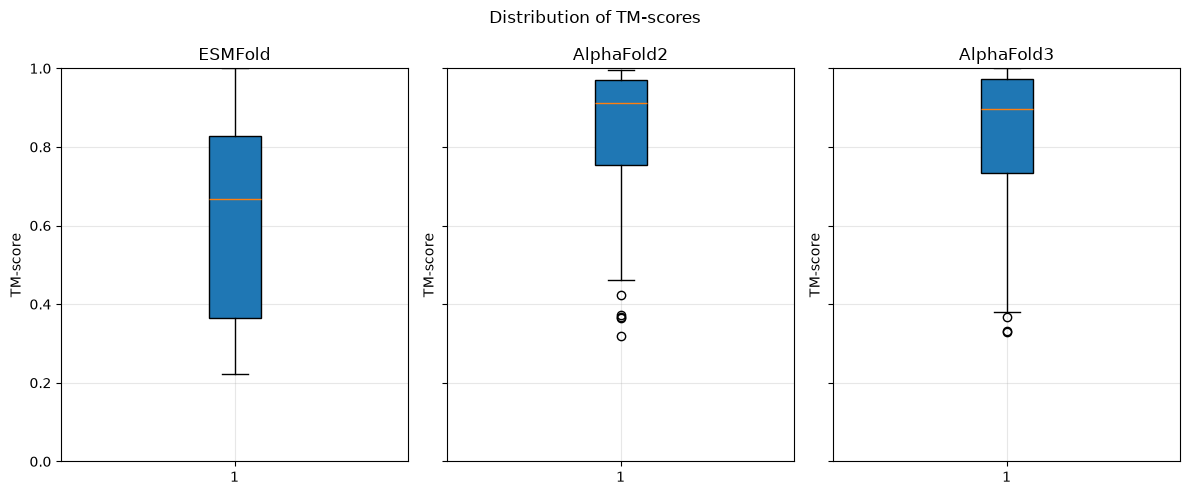

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)

for ax, col, title in zip(axes, tm_columns, titles):

    ax.boxplot(
        df[col].dropna(),
        vert=True,
        patch_artist=True
    )

    ax.set_title(title)
    ax.set_ylabel("TM-score")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

plt.suptitle("Distribution of TM-scores")
plt.tight_layout()
plt.show()

In [18]:
# Simplify the families
families = {
    "AvrSr35-like",
    "FOLD",
    "KP4-like",
    "LARS",
    "MAX",
    "RALPH",
    "ToxA-like",
}

def simplify_family(family):
    family = str(family).strip()
    return family if family in families else "Other"

df["Structural_family_simplified"] = df[
    "Structural family (inferred from La Naour Vernet et al. (2025))"
].apply(simplify_family)

print(df["Structural_family_simplified"].value_counts())

Structural_family_simplified
Other           29
MAX             26
RALPH            7
ToxA-like        6
LARS             4
AvrSr35-like     4
FOLD             3
KP4-like         2
Name: count, dtype: int64


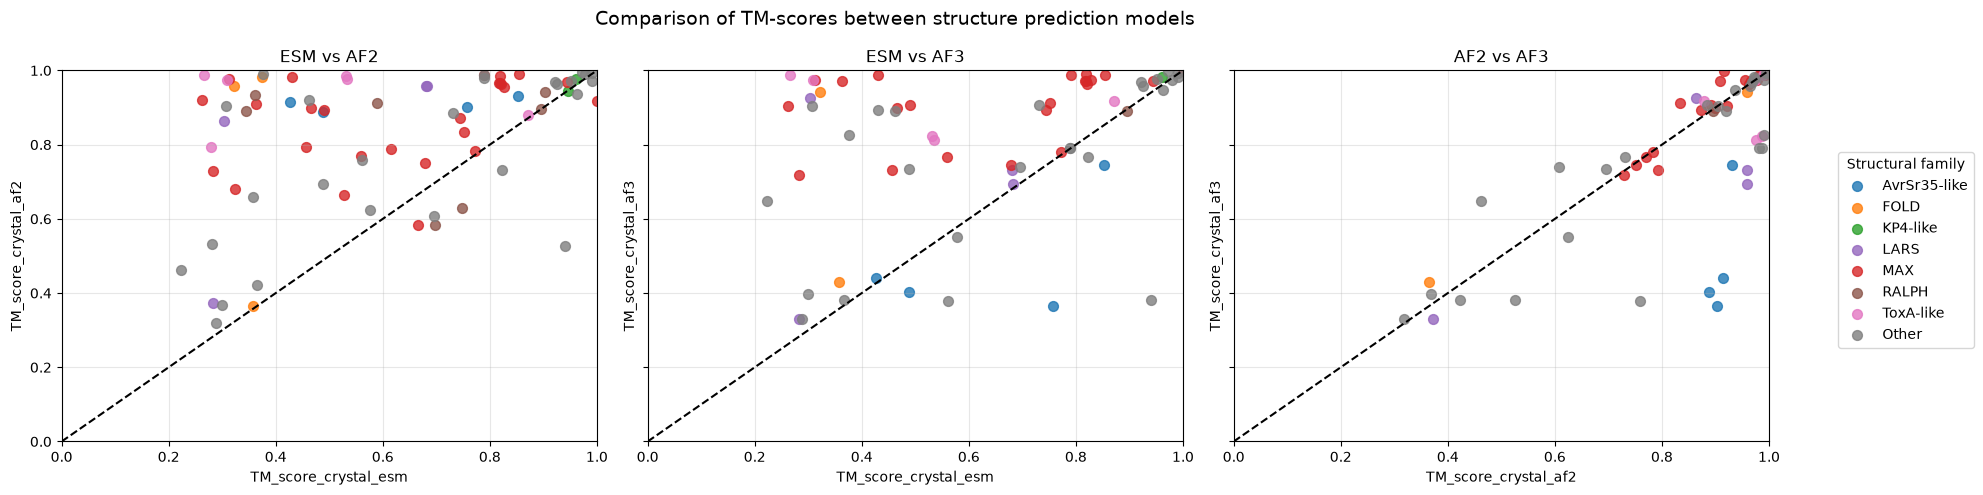

In [ ]:
# Define the order of structural families
family_order = [
    'AvrSr35-like',
    'FOLD',
    'KP4-like',
    'LARS',
    'MAX',
    'RALPH',
    'ToxA-like',
    'Other'
]

# Colour mapping
family_colors = {
    'AvrSr35-like': 'tab:blue',
    'FOLD': 'tab:orange',
    'KP4-like': 'tab:green',
    'LARS': 'tab:purple',
    'MAX': 'tab:red',
    'RALPH': 'tab:brown',
    'ToxA-like': 'tab:pink',
    'Other': 'tab:gray'
}

comparisons = [
    ("TM_score_crystal_esm", "TM_score_crystal_af2", "ESM vs AF2"),
    ("TM_score_crystal_esm", "TM_score_crystal_af3", "ESM vs AF3"),
    ("TM_score_crystal_af2", "TM_score_crystal_af3", "AF2 vs AF3"),
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    sharex=True,
    sharey=True
)


for ax, (xcol, ycol, title) in zip(axes, comparisons):

    for family in family_order:

        subset = df[
            df["Structural_family_simplified"] == family
        ]

        ax.scatter(
            subset[xcol],
            subset[ycol],
            label=family,
            color=family_colors[family],
            s=50,
            alpha=0.8
        )

    # perfect agreement line
    ax.plot(
        [0, 1],
        [0, 1],
        "--",
        color="black"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)

    ax.set_title(title)

    ax.grid(alpha=0.3)


# one shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Structural family",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

fig.suptitle(
    "Comparison of TM-scores between structure prediction models",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [22]:
organism_map = {
    "blumeria hordei": "Blumeria hordei",
    "fusarium oxysporum": "Fusarium oxysporum",
    "magnaporthe oryzae": "Magnaporthe oryzae",
    "pyricularia oryzae": "Magnaporthe oryzae",
    "puccinia graminis": "Puccinia graminis",
    "pyrenophora tritici-repentis": "Pyrenophora tritici-repentis",
}

def simplify_organism(org):
    org = str(org).lower()

    for key, value in organism_map.items():
        if key in org:
            return value

    return "Other"


df["Organism_simplified"] = df["Organism"].apply(simplify_organism)

print(df["Organism_simplified"].value_counts())

Organism_simplified
Other                           33
Magnaporthe oryzae              26
Fusarium oxysporum               8
Puccinia graminis                6
Pyrenophora tritici-repentis     4
Blumeria hordei                  4
Name: count, dtype: int64


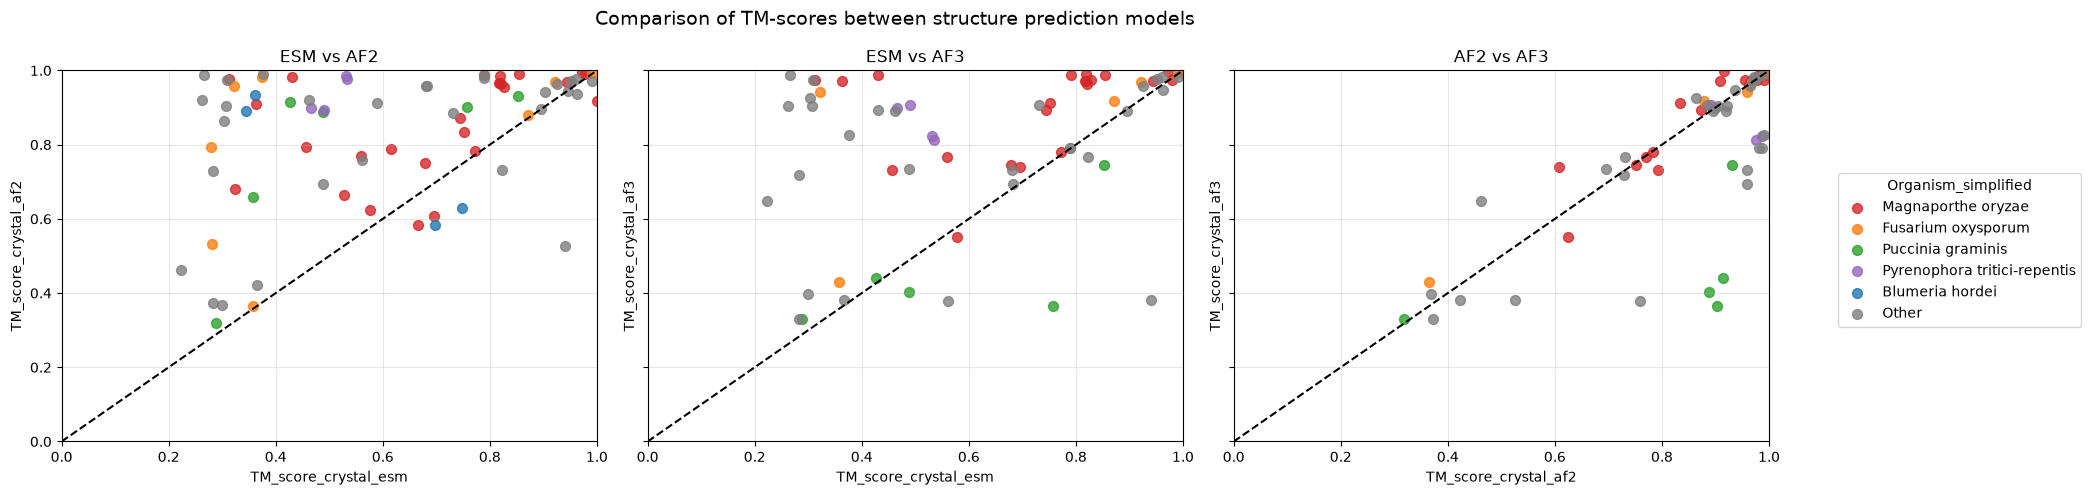

In [23]:
# Define the order of structural families
family_order = [
    'Magnaporthe oryzae',
    'Fusarium oxysporum',
    'Puccinia graminis',
    'Pyrenophora tritici-repentis',
    'Blumeria hordei',
    'Other'
]

# Colour mapping
family_colors = {
    'Other': 'tab:gray',
    'Magnaporthe oryzae': 'tab:red',
    'Fusarium oxysporum':'tab:orange',
    'Puccinia graminis':'tab:green',
    'Pyrenophora tritici-repentis':'tab:purple',
    'Blumeria hordei':'tab:blue'
}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    sharex=True,
    sharey=True
)


for ax, (xcol, ycol, title) in zip(axes, comparisons):

    for family in family_order:

        subset = df[
            df["Organism_simplified"] == family
        ]

        ax.scatter(
            subset[xcol],
            subset[ycol],
            label=family,
            color=family_colors[family],
            s=50,
            alpha=0.8
        )

    # perfect agreement line
    ax.plot(
        [0, 1],
        [0, 1],
        "--",
        color="black"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)

    ax.set_title(title)

    ax.grid(alpha=0.3)


# one shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Organism_simplified",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

fig.suptitle(
    "Comparison of TM-scores between structure prediction models",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [24]:
def simplify_method(method):

    method = str(method).lower()

    if "nmr" in method:
        return "Solution NMR"

    elif "x-ray" in method or "xray" in method:
        return "X-ray"

    elif "electron" in method or "em" in method:
        return "Electron microscopy"

    else:
        return "Other"

df["Method_simplified"] = df["Method"].apply(simplify_method)
print(df["Method_simplified"].value_counts())

Method_simplified
X-ray                  59
Solution NMR           16
Electron microscopy     4
Other                   2
Name: count, dtype: int64


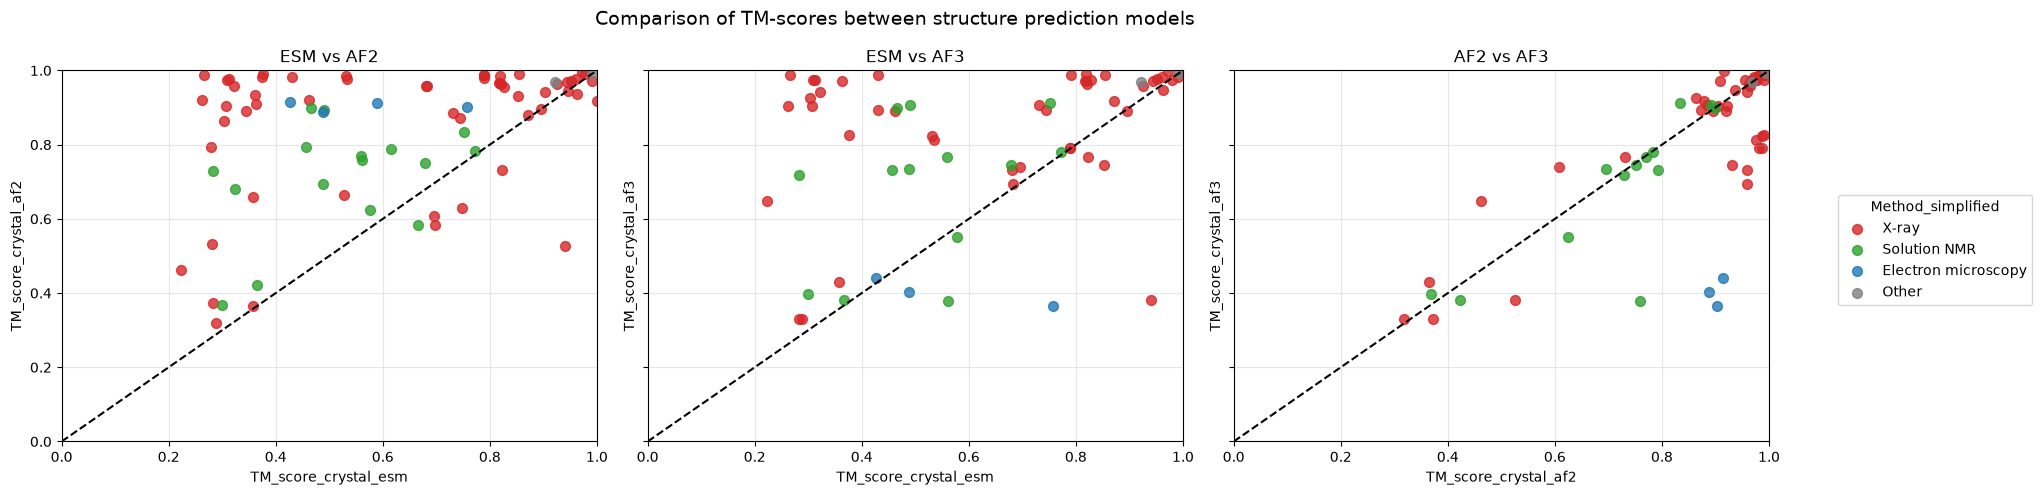

In [25]:
# Define the order of structural families
family_order = [
    'X-ray',
    'Solution NMR',
    'Electron microscopy',
    'Other',
]

# Colour mapping
family_colors = {
    'X-ray': 'tab:red',
    'Solution NMR':'tab:green',
    'Electron microscopy':'tab:blue',
    'Other' :'tab:gray',
}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    sharex=True,
    sharey=True
)


for ax, (xcol, ycol, title) in zip(axes, comparisons):

    for family in family_order:

        subset = df[
            df["Method_simplified"] == family
        ]

        ax.scatter(
            subset[xcol],
            subset[ycol],
            label=family,
            color=family_colors[family],
            s=50,
            alpha=0.8
        )

    # perfect agreement line
    ax.plot(
        [0, 1],
        [0, 1],
        "--",
        color="black"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)

    ax.set_title(title)

    ax.grid(alpha=0.3)


# one shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Method_simplified",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

fig.suptitle(
    "Comparison of TM-scores between structure prediction models",
    fontsize=14
)

plt.tight_layout()
plt.show()

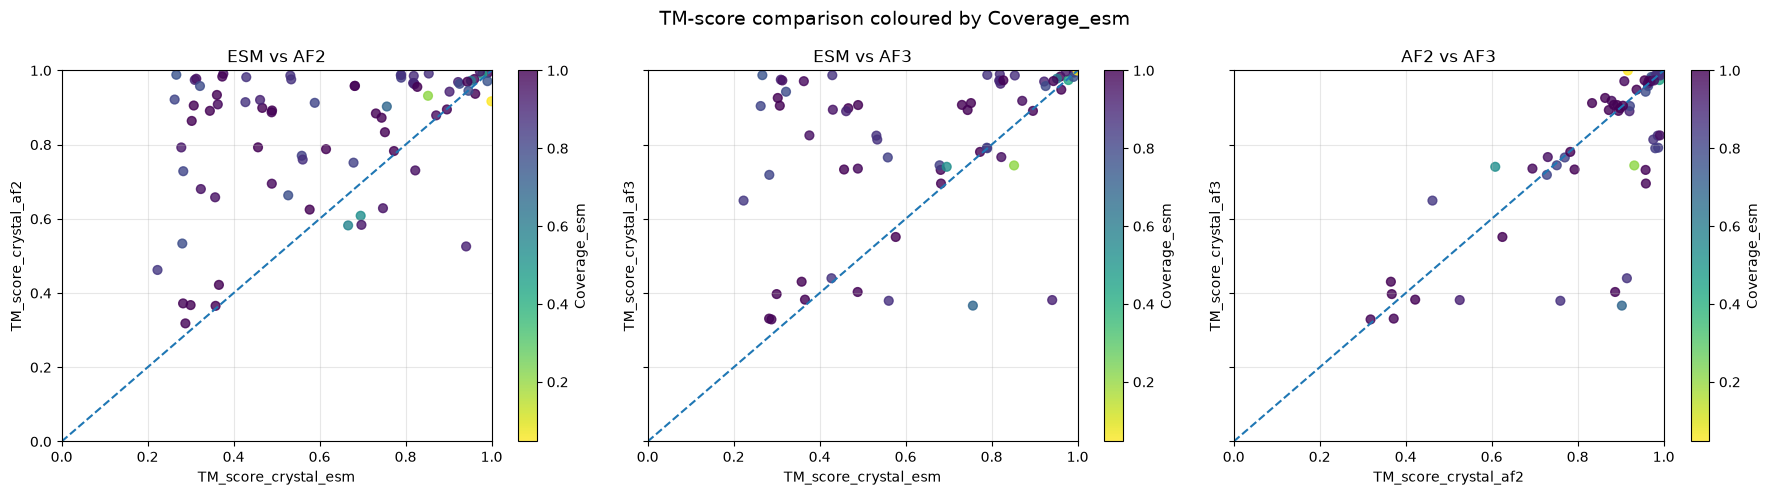

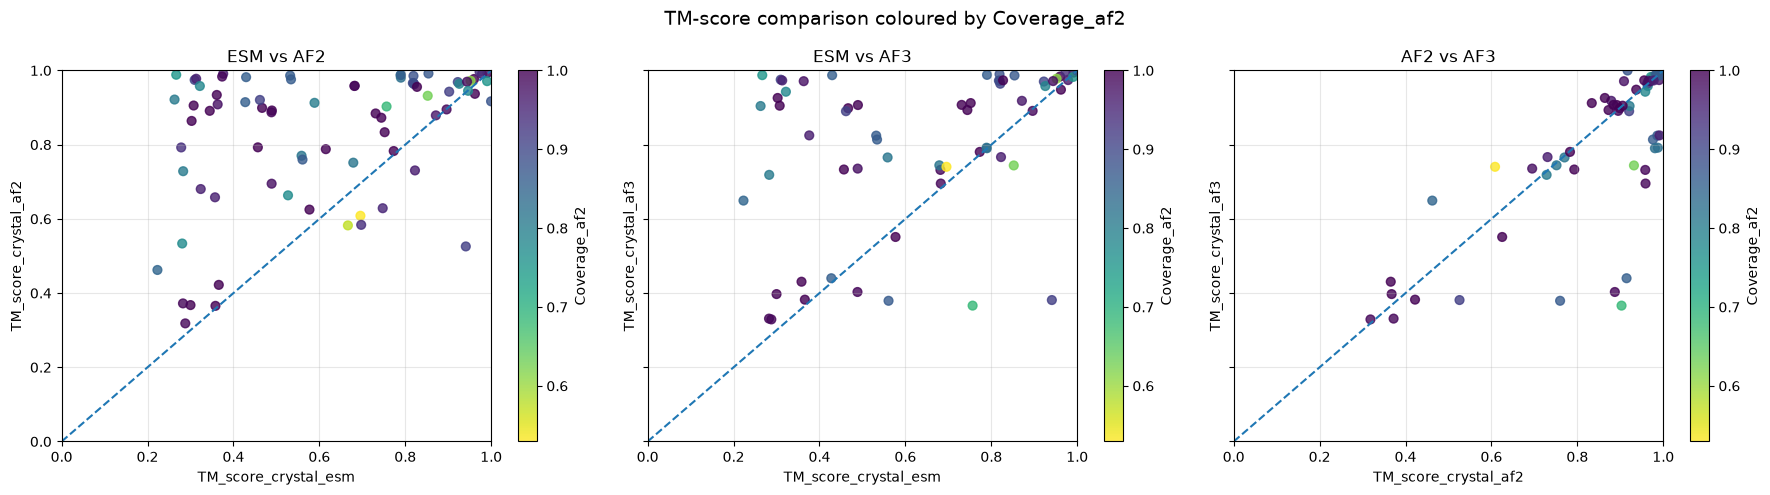

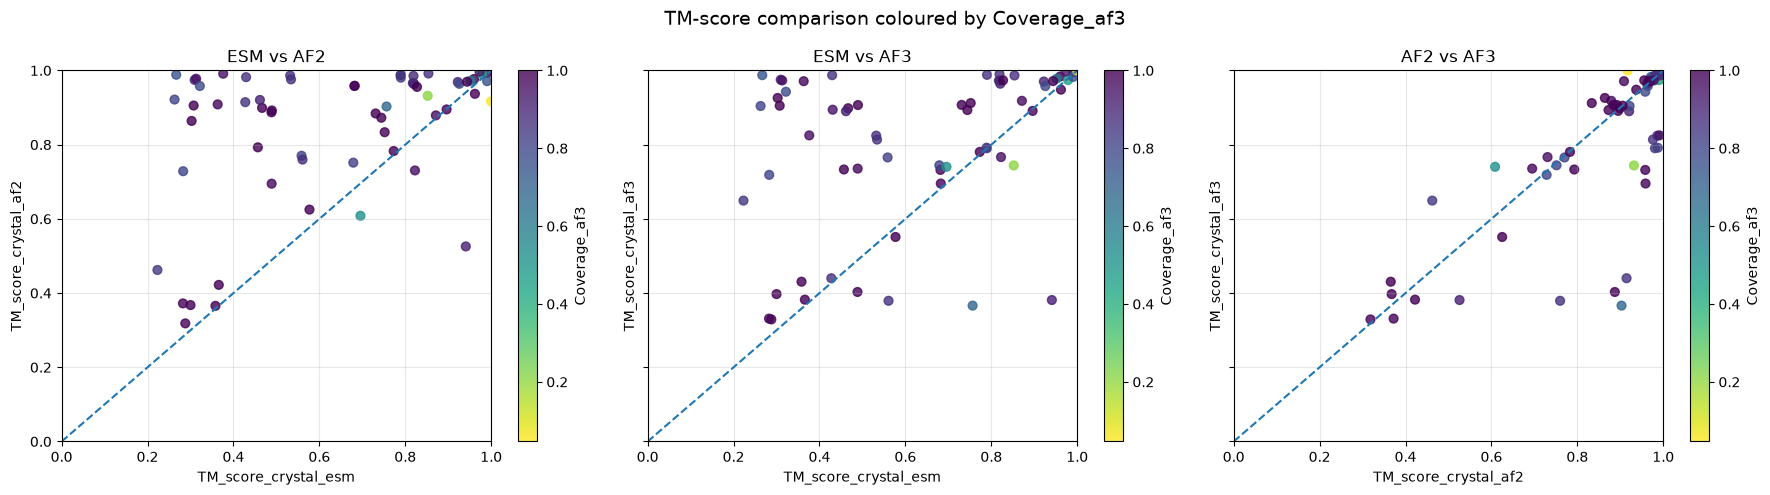

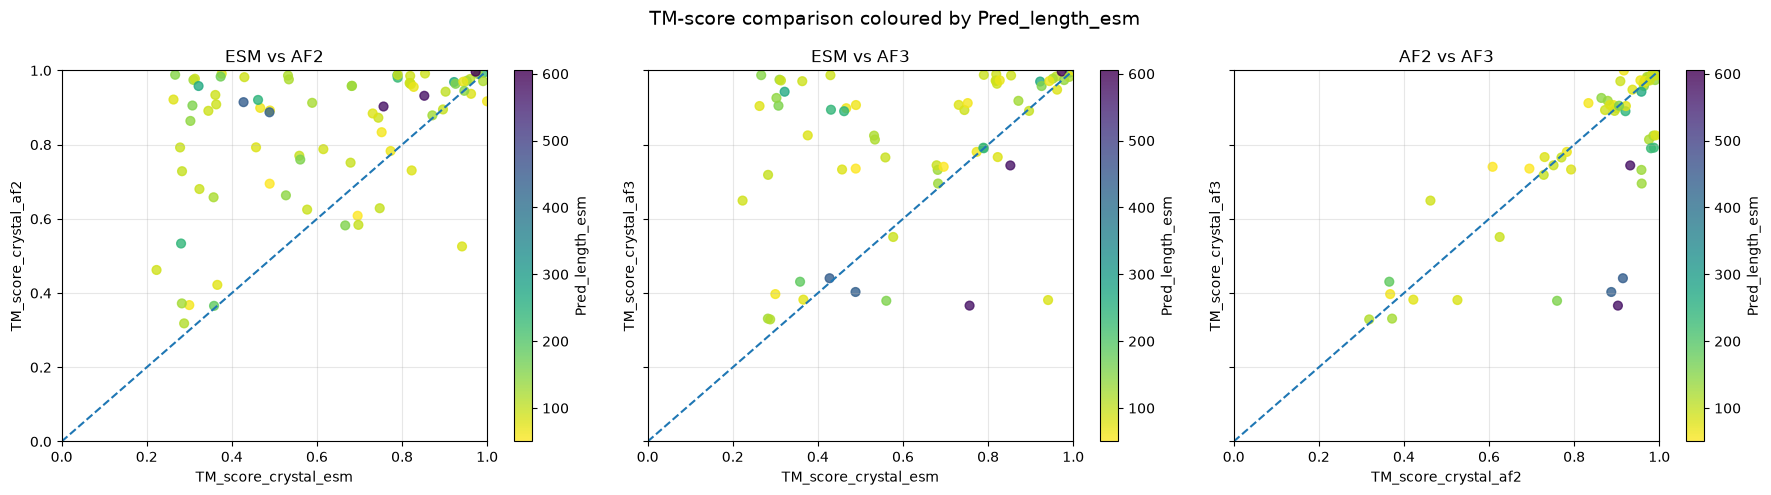

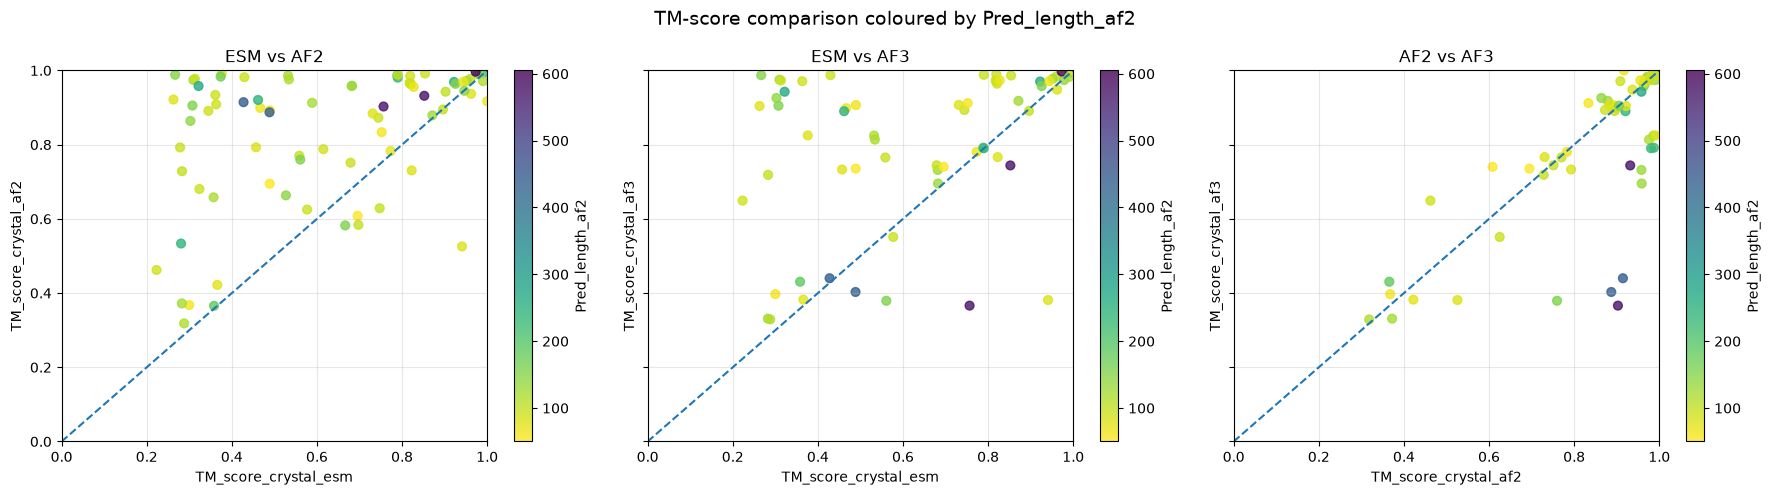

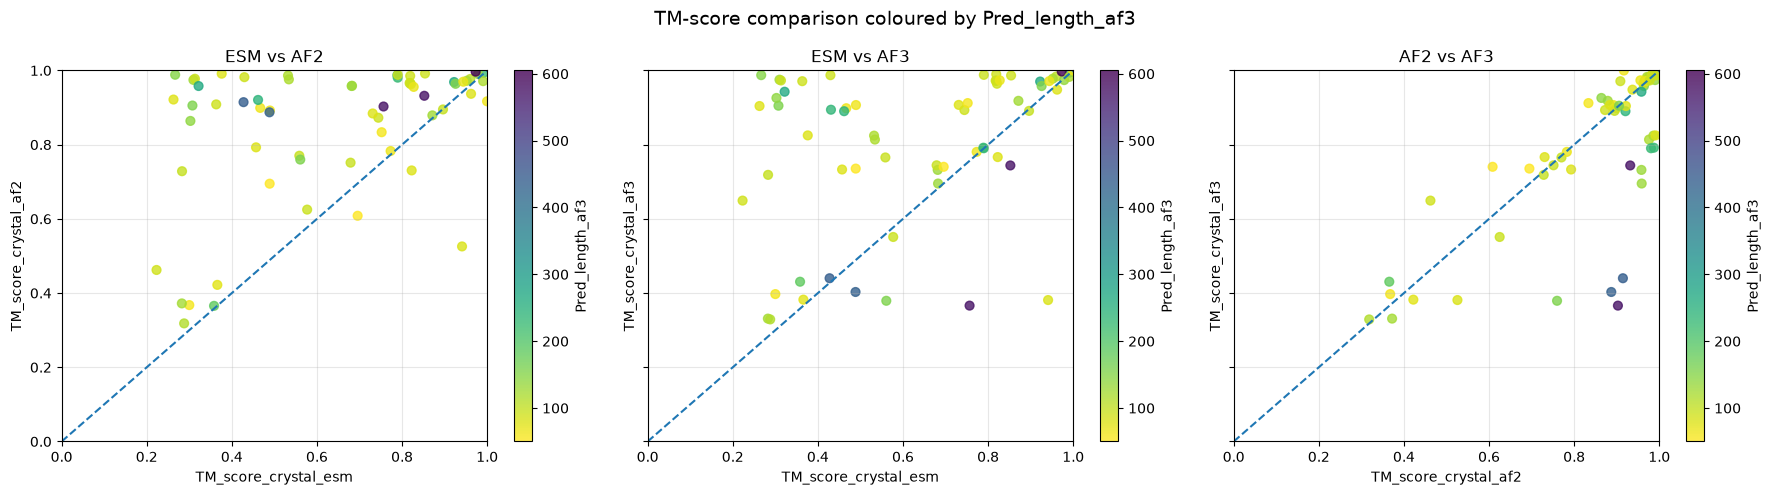

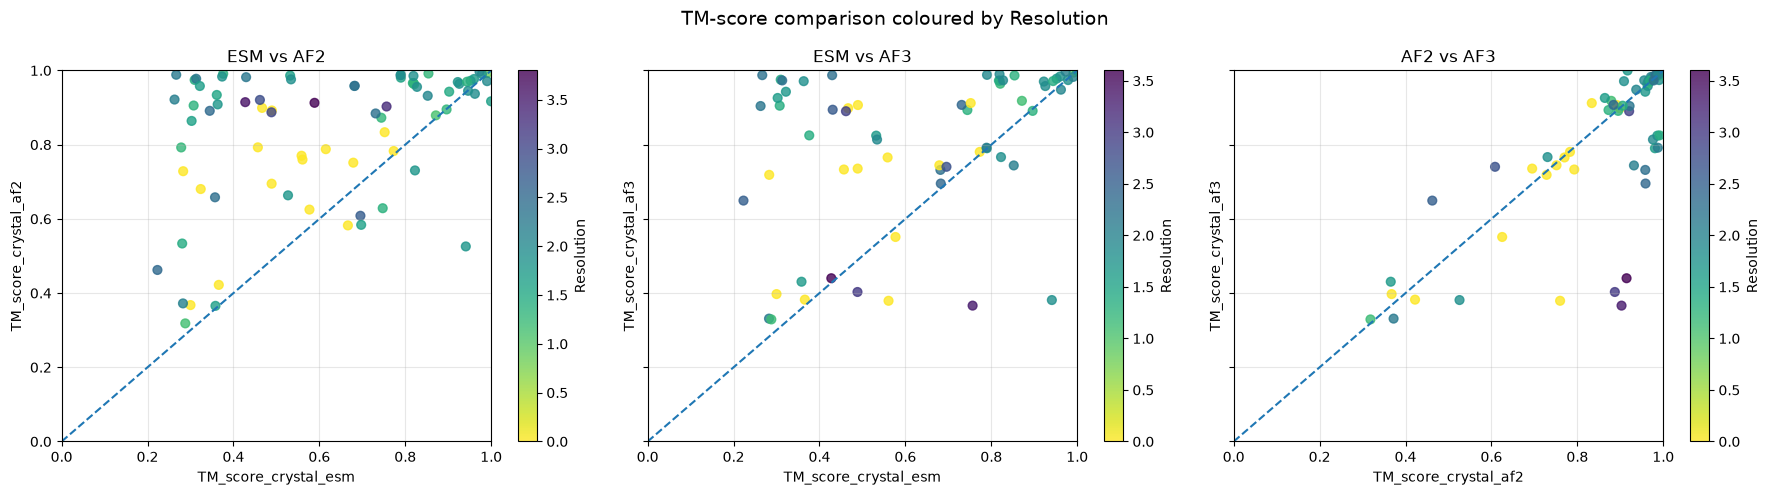

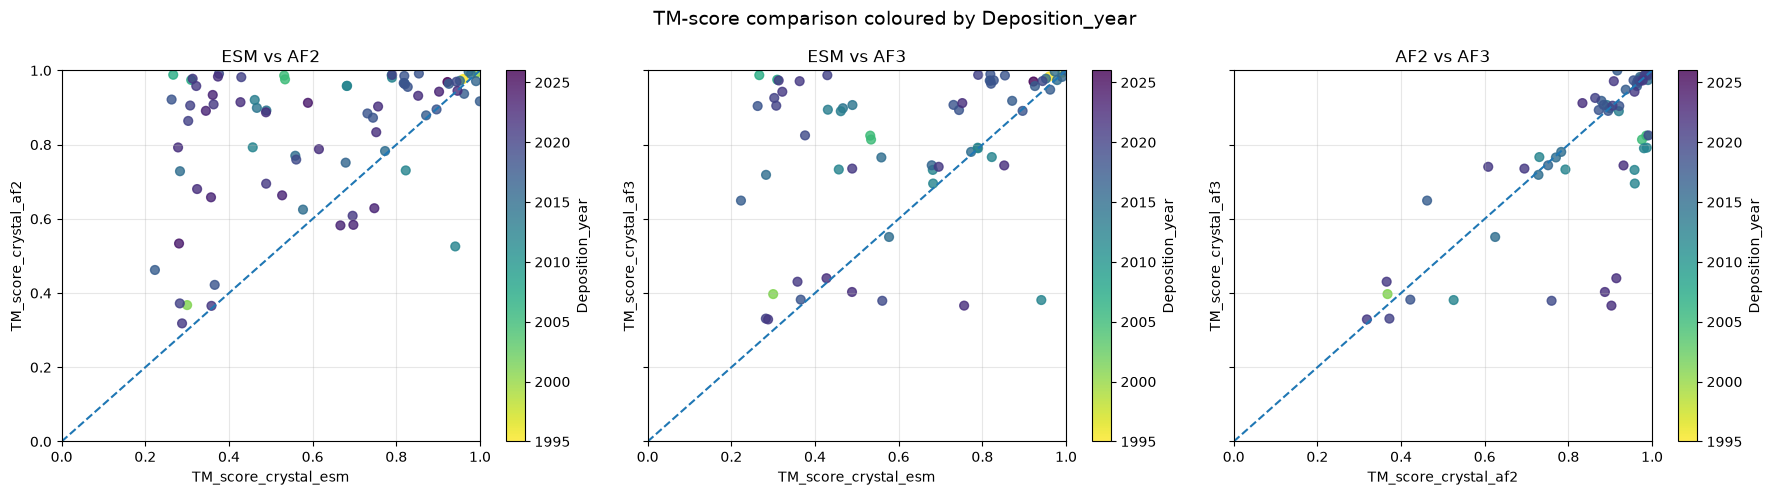

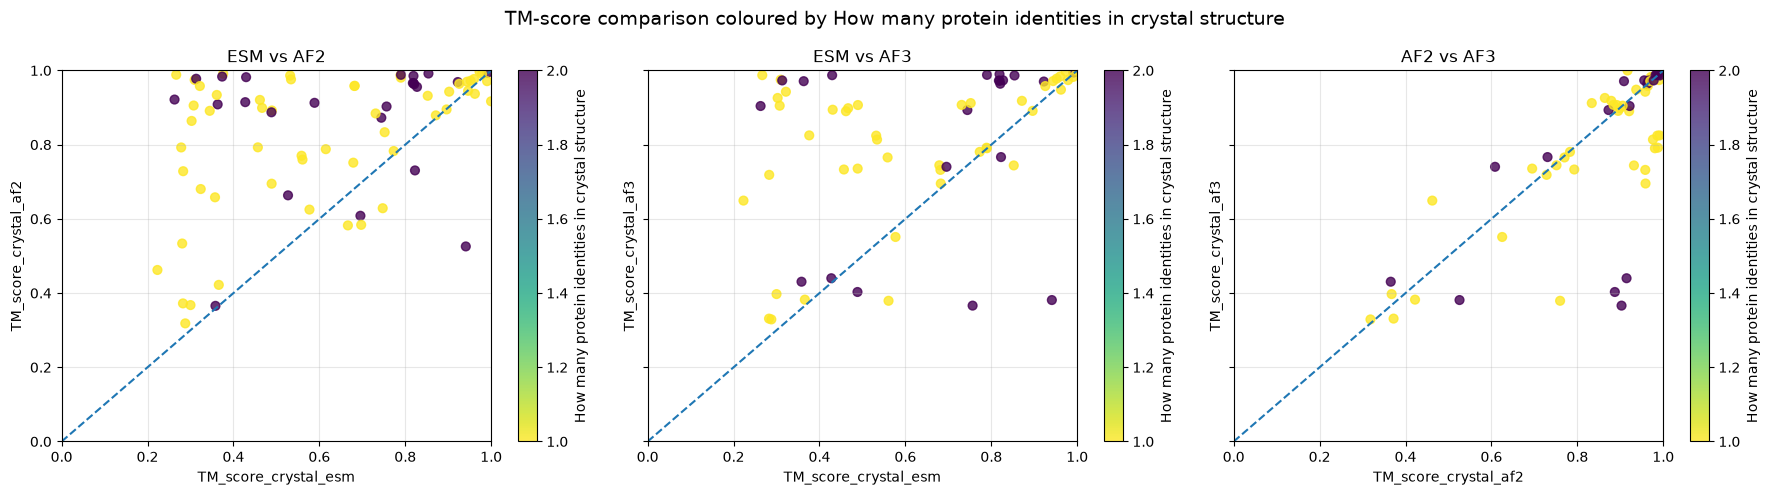

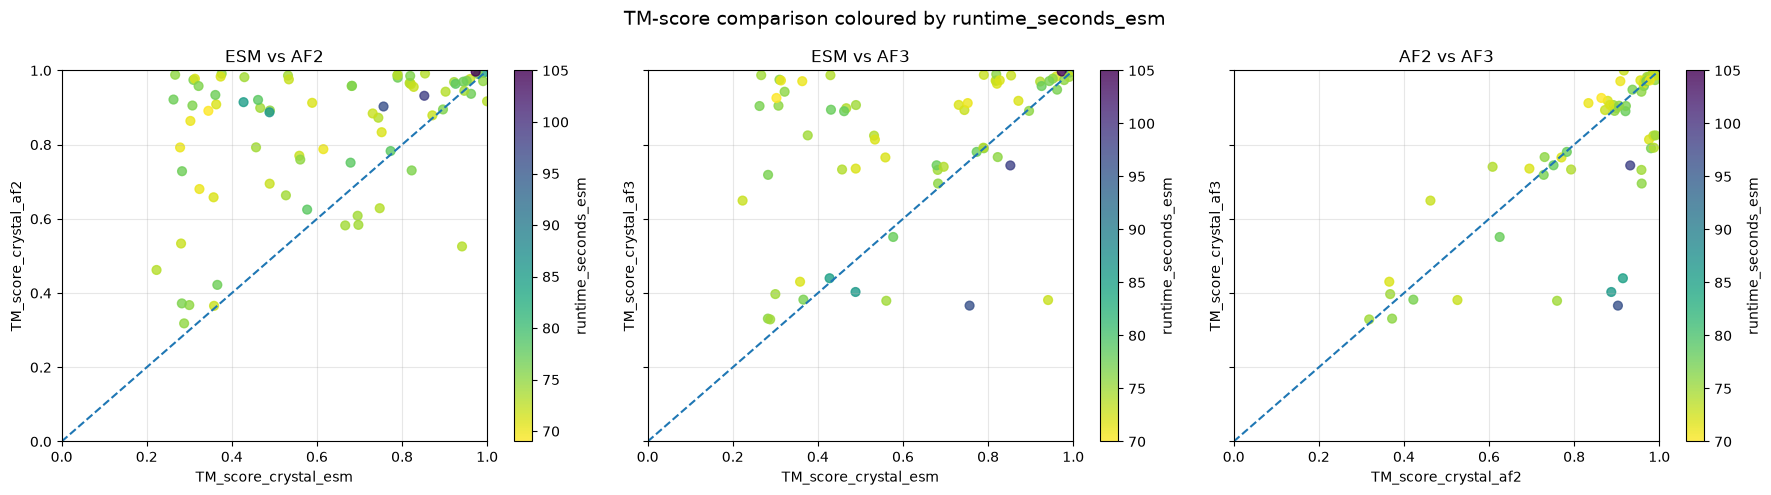

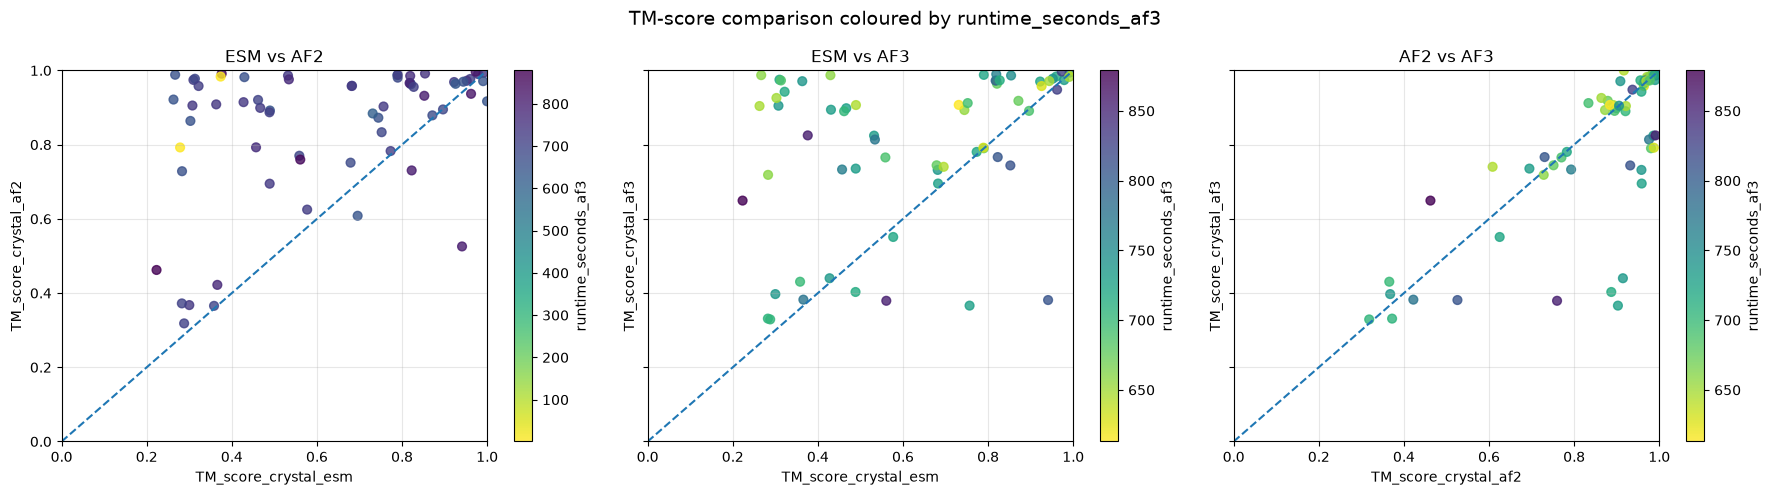

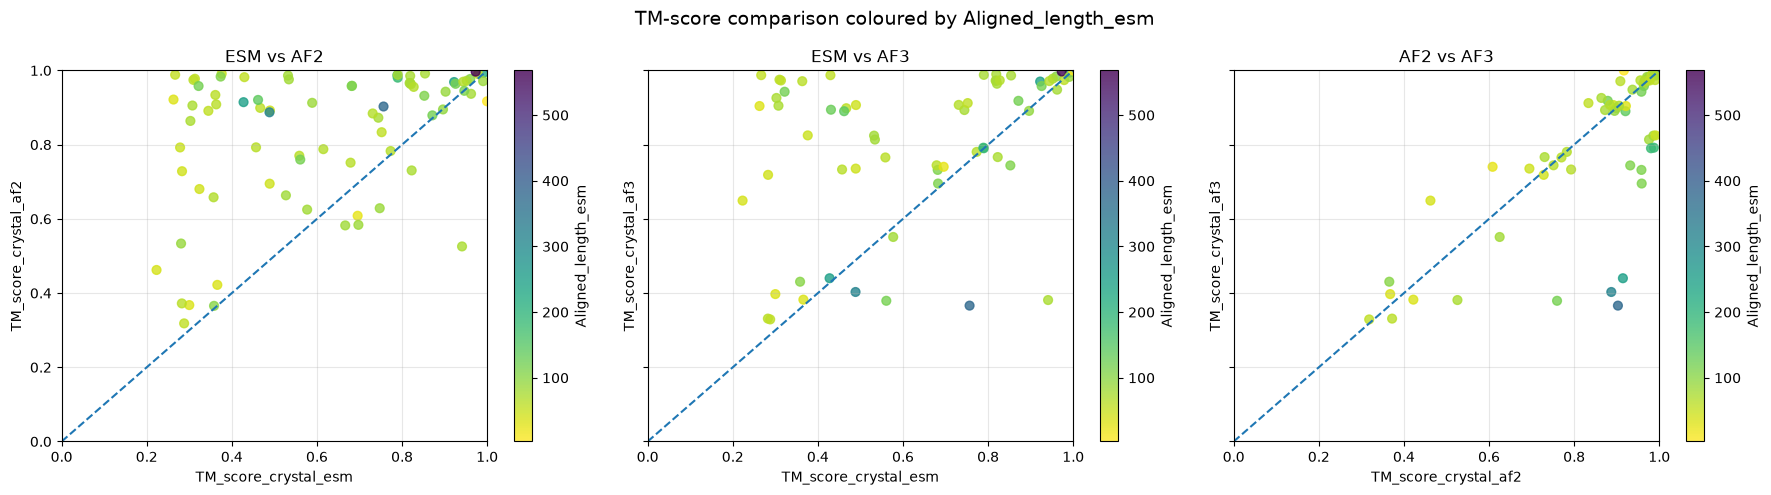

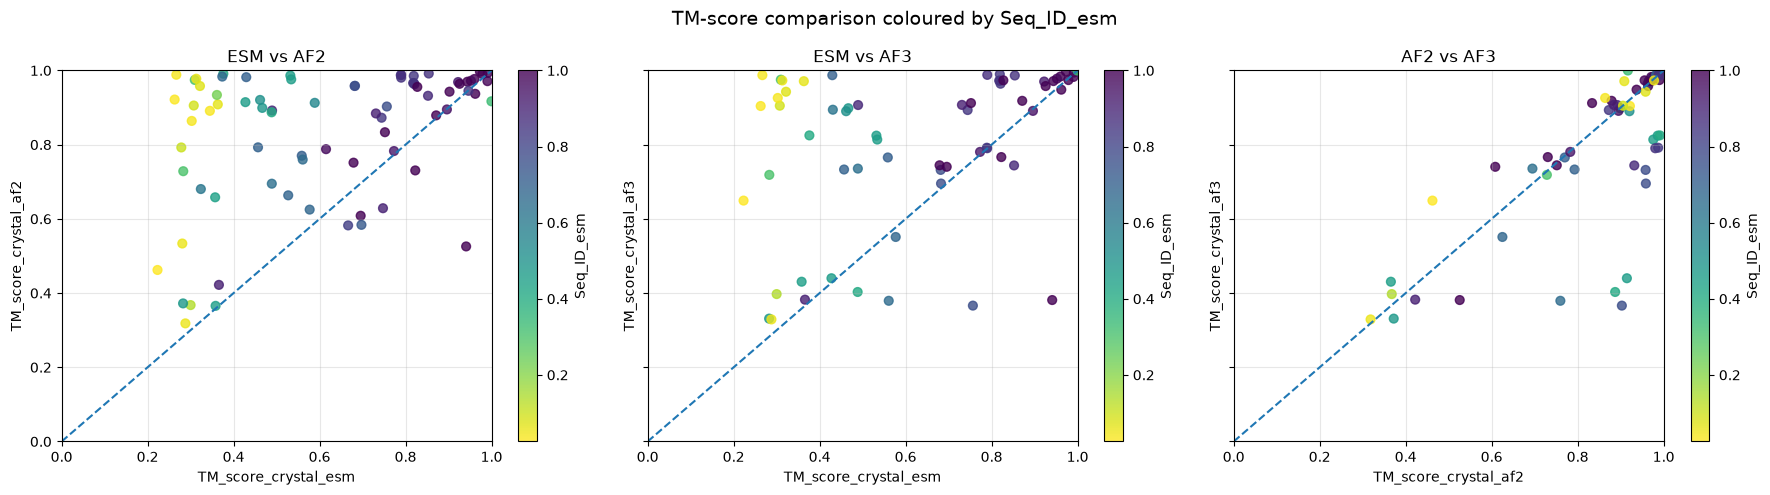

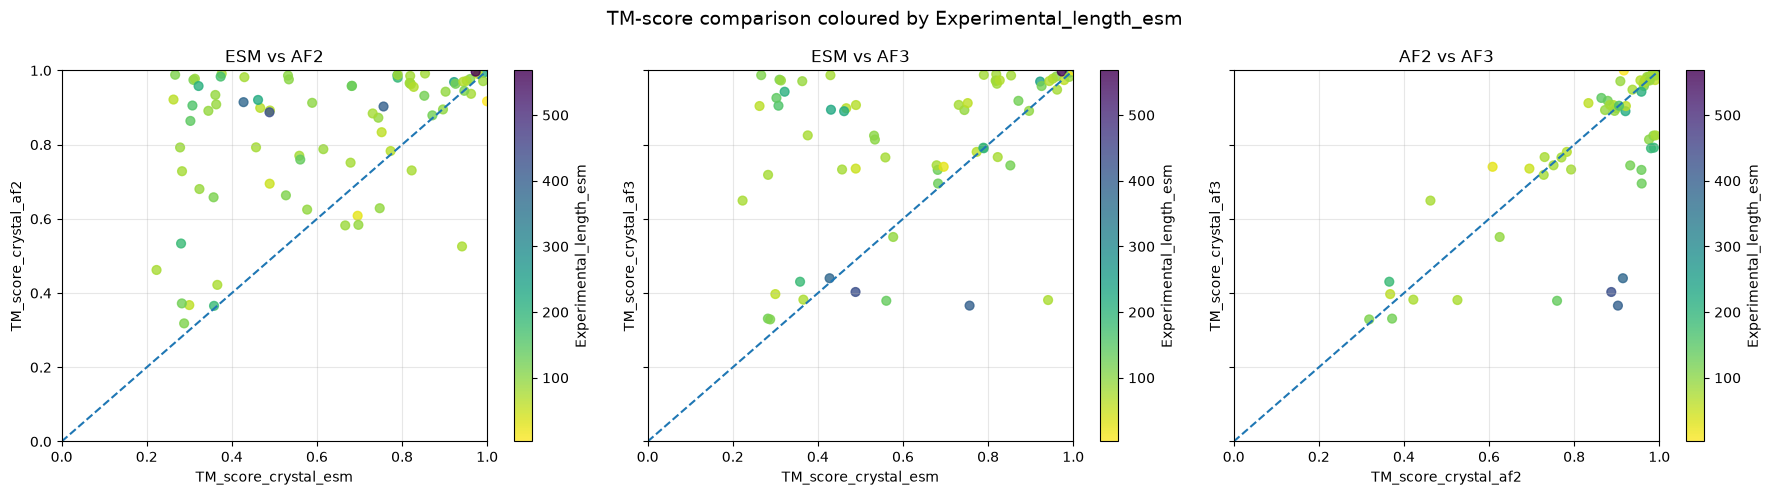

In [40]:
df["Deposition_year"] = pd.to_datetime(
    df["Deposition_date"]
).dt.year

continuous_metadata = [
    "Coverage_esm",
    "Coverage_af2",
    "Coverage_af3",
    "Pred_length_esm",
    "Pred_length_af2",
    "Pred_length_af3",
    "Resolution",
    "Deposition_year",
    "How many protein identities in crystal structure",
    "runtime_seconds_esm",
    "runtime_seconds_af3",
    "Aligned_length_esm",
    "Seq_ID_esm",
    'Experimental_length_esm'
]

# ['TM_score_pred_esm', 'RMSD_esm', 'Aligned_length_esm', 'Seq_ID_esm', 'Pred_length_esm', 'Experimental_length_esm', 'Coverage_esm', 'runtime_seconds_esm', 'TM_score_crystal_af2', 'TM_score_pred_af2', 'RMSD_af2', 'Aligned_length_af2', 'Seq_ID_af2', 'Pred_length_af2', 'Experimental_length_af2', 'Coverage_af2', 'TM_score_crystal_af3', 'TM_score_pred_af3', 'RMSD_af3', 'Aligned_length_af3', 'Seq_ID_af3', 'Pred_length_af3', 'Experimental_length_af3', 'Coverage_af3', 'runtime_seconds_af3', 'Structural family (inferred from La Naour Vernet et al. (2025))', 'How many protein identities in crystal structure', 'Method', 'Resolution']

for colour_column in continuous_metadata:

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 5),
        sharex=True,
        sharey=True
    )

    for ax, (xcol, ycol, title) in zip(axes, comparisons):

        scatter = ax.scatter(
            df[xcol],
            df[ycol],
            c=df[colour_column],
            cmap="viridis_r",
            s=40,
            alpha=0.8
        )

        cbar = plt.colorbar(
            scatter,
            ax=ax
        )

        cbar.set_label(colour_column)

        # diagonal = equal performance
        ax.plot(
            [0, 1],
            [0, 1],
            "--"
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.set_xlabel(xcol)
        ax.set_ylabel(ycol)

        ax.set_title(title)

        ax.grid(alpha=0.3)

    fig.suptitle(
        f"TM-score comparison coloured by {colour_column}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()
    plt.close()